<a href="https://colab.research.google.com/github/yasirsiddiq01/binary-classification-pytorch/blob/main/simple_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import os
import argparse
from datetime import datetime

In [3]:
import torch

In [5]:
import torch.nn as nn

In [6]:
# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

class BinaryClassifier(nn.Module):
    """
    A simple feedforward neural network for binary classification

    Architecture:
    - Input Layer: 6 features
    - Hidden Layer 1: 4 neurons with ReLU activation
    - Hidden Layer 2: 4 neurons with Sigmoid activation
    - Output: 1 neuron with Sigmoid (binary probability)
    """

    def __init__(self, input_size=6, hidden_size=4, output_size=1):
        super(BinaryClassifier, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.Sigmoid(),  # Hidden layer activation
            nn.Linear(hidden_size, output_size),
            nn.Sigmoid()   # Output activation for binary classification
        )

    def forward(self, x):
        return self.model(x)


In [7]:
class DataGenerator:
    """Generate synthetic dataset for binary classification"""

    @staticmethod
    def generate_dataset(n_samples=1000, n_features=6, noise=0.1):
        """
        Generate synthetic dataset with 6 features
        Creates two classes with different statistical properties
        """
        # Class 0: Centered around 0 with some spread
        class0 = np.random.randn(n_samples // 2, n_features) * noise + 0

        # Class 1: Centered around 1 with some spread
        class1 = np.random.randn(n_samples // 2, n_features) * noise + 1

        # Combine data
        X = np.vstack([class0, class1])
        y = np.hstack([np.zeros(n_samples // 2), np.ones(n_samples // 2)])

        # Shuffle the data
        indices = np.random.permutation(n_samples)
        X = X[indices]
        y = y[indices]

        return X, y

    @staticmethod
    def generate_custom_dataset():
        """
        Generate a more realistic dataset
        This could be replaced with actual data loading (CSV, etc.)
        """
        # Example: Medical diagnosis scenario
        # Features: [age, blood_pressure, cholesterol, bmi, glucose, heart_rate]

        n_samples = 1000

        # Healthy patients (class 0)
        healthy = np.array([
            np.random.normal(45, 10, n_samples//2),      # age
            np.random.normal(120, 10, n_samples//2),     # blood pressure
            np.random.normal(180, 20, n_samples//2),     # cholesterol
            np.random.normal(24, 3, n_samples//2),       # bmi
            np.random.normal(90, 10, n_samples//2),      # glucose
            np.random.normal(70, 10, n_samples//2)       # heart rate
        ]).T

        # Sick patients (class 1) - with elevated risk factors
        sick = np.array([
            np.random.normal(60, 10, n_samples//2),      # age (older)
            np.random.normal(140, 15, n_samples//2),     # blood pressure (higher)
            np.random.normal(240, 30, n_samples//2),     # cholesterol (higher)
            np.random.normal(30, 4, n_samples//2),       # bmi (higher)
            np.random.normal(140, 20, n_samples//2),     # glucose (higher)
            np.random.normal(85, 15, n_samples//2)       # heart rate (higher)
        ]).T

        X = np.vstack([healthy, sick])
        y = np.hstack([np.zeros(n_samples//2), np.ones(n_samples//2)])

        # Shuffle
        indices = np.random.permutation(n_samples)
        return X[indices], y[indices]


In [8]:
class Trainer:
    """Handle model training and evaluation"""

    def __init__(self, model, criterion, optimizer, device='cpu'):
        self.model = model.to(device)
        self.criterion = criterion
        self.optimizer = optimizer
        self.device = device
        self.train_losses = []
        self.val_losses = []
        self.train_accuracies = []
        self.val_accuracies = []

    def train_epoch(self, train_loader):
        """Train for one epoch"""
        self.model.train()
        total_loss = 0
        correct = 0
        total = 0

        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(self.device), batch_y.to(self.device)

            # Forward pass
            outputs = self.model(batch_X)
            loss = self.criterion(outputs, batch_y)

            # Backward pass
            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()

            # Statistics
            total_loss += loss.item()
            predicted = (outputs > 0.5).float()
            total += batch_y.size(0)
            correct += (predicted == batch_y).sum().item()

        return total_loss / len(train_loader), correct / total

    def validate(self, val_loader):
        """Validate the model"""
        self.model.eval()
        total_loss = 0
        correct = 0
        total = 0
        all_predictions = []
        all_labels = []

        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X, batch_y = batch_X.to(self.device), batch_y.to(self.device)

                outputs = self.model(batch_X)
                loss = self.criterion(outputs, batch_y)

                total_loss += loss.item()
                predicted = (outputs > 0.5).float()
                total += batch_y.size(0)
                correct += (predicted == batch_y).sum().item()

                all_predictions.extend(predicted.cpu().numpy())
                all_labels.extend(batch_y.cpu().numpy())

        return (total_loss / len(val_loader), correct / total,
                np.array(all_predictions), np.array(all_labels))

    def train(self, train_loader, val_loader, epochs=100, early_stopping_patience=10):
        """Full training loop"""
        best_val_acc = 0
        patience_counter = 0
        best_model_state = None

        for epoch in range(epochs):
            # Train
            train_loss, train_acc = self.train_epoch(train_loader)
            self.train_losses.append(train_loss)
            self.train_accuracies.append(train_acc)

            # Validate
            val_loss, val_acc, _, _ = self.validate(val_loader)
            self.val_losses.append(val_loss)
            self.val_accuracies.append(val_acc)

            # Print progress
            if (epoch + 1) % 10 == 0:
                print(f'Epoch [{epoch+1}/{epochs}], '
                      f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, '
                      f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')

            # Early stopping
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                patience_counter = 0
                best_model_state = copy.deepcopy(self.model.state_dict())
            else:
                patience_counter += 1

            if patience_counter >= early_stopping_patience:
                print(f'Early stopping at epoch {epoch+1}')
                break

        # Load best model
        if best_model_state:
            self.model.load_state_dict(best_model_state)

        return self.model


In [9]:
class Visualizer:
    """Handle all visualization tasks"""

    @staticmethod
    def plot_training_history(trainer, save_path='training_history.png'):
        """Plot training and validation loss/accuracy"""
        fig, axes = plt.subplots(1, 2, figsize=(15, 5))

        # Plot losses
        axes[0].plot(trainer.train_losses, label='Train Loss', color='blue')
        axes[0].plot(trainer.val_losses, label='Validation Loss', color='red')
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Loss')
        axes[0].set_title('Training and Validation Loss')
        axes[0].legend()
        axes[0].grid(True)

        # Plot accuracies
        axes[1].plot(trainer.train_accuracies, label='Train Accuracy', color='blue')
        axes[1].plot(trainer.val_accuracies, label='Validation Accuracy', color='red')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Accuracy')
        axes[1].set_title('Training and Validation Accuracy')
        axes[1].legend()
        axes[1].grid(True)

        plt.tight_layout()
        plt.savefig(save_path)
        plt.show()

    @staticmethod
    def plot_confusion_matrix(y_true, y_pred, save_path='confusion_matrix.png'):
        """Plot confusion matrix"""
        cm = confusion_matrix(y_true, y_pred)

        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                   xticklabels=['Class 0', 'Class 1'],
                   yticklabels=['Class 0', 'Class 1'])
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.title('Confusion Matrix')
        plt.tight_layout()
        plt.savefig(save_path)
        plt.show()

    @staticmethod
    def plot_feature_importance(model, feature_names=None):
        """Simple feature importance visualization using first layer weights"""
        weights = model.model[0].weight.data.cpu().numpy()
        importance = np.abs(weights).mean(axis=0)

        if feature_names is None:
            feature_names = [f'Feature {i}' for i in range(len(importance))]

        plt.figure(figsize=(10, 6))
        plt.bar(feature_names, importance)
        plt.xlabel('Features')
        plt.ylabel('Average Absolute Weight')
        plt.title('Feature Importance (based on first layer weights)')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.savefig('feature_importance.png')
        plt.show()


In [11]:
def main():
    """Main execution function"""
    parser = argparse.ArgumentParser(description='Binary Classification Neural Network')
    parser.add_argument('--epochs', type=int, default=100, help='Number of training epochs')
    parser.add_argument('--batch_size', type=int, default=32, help='Batch size')
    parser.add_argument('--lr', type=float, default=0.001, help='Learning rate')
    parser.add_argument('--hidden_size', type=int, default=4, help='Hidden layer size')
    parser.add_argument('--noise', type=float, default=0.1, help='Noise level in data')
    args = parser.parse_args()

    # Check device
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    # Generate data
    print("Generating synthetic dataset...")
    X, y = DataGenerator.generate_dataset(n_samples=1000, n_features=6, noise=args.noise)

    # Split data
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

    # Normalize features
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
    X_test = scaler.transform(X_test)

    # Convert to tensors
    X_train_tensor = torch.FloatTensor(X_train)
    y_train_tensor = torch.FloatTensor(y_train).view(-1, 1)
    X_val_tensor = torch.FloatTensor(X_val)
    y_val_tensor = torch.FloatTensor(y_val).view(-1, 1)
    X_test_tensor = torch.FloatTensor(X_test)
    y_test_tensor = torch.FloatTensor(y_test).view(-1, 1)

    # Create data loaders
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
    test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

    train_loader = DataLoader(train_dataset, batch_size=args.batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=args.batch_size)
    test_loader = DataLoader(test_dataset, batch_size=args.batch_size)

    # Initialize model
    model = BinaryClassifier(input_size=6, hidden_size=args.hidden_size)
    criterion = nn.BCELoss()  # Binary Cross Entropy Loss
    optimizer = optim.Adam(model.parameters(), lr=args.lr)

    # Train model
    print("Starting training...")
    trainer = Trainer(model, criterion, optimizer, device)
    trained_model = trainer.train(train_loader, val_loader, epochs=args.epochs)

    # Evaluate on test set
    print("\nEvaluating on test set...")
    test_loss, test_acc, test_preds, test_labels = trainer.validate(test_loader)

    # Calculate additional metrics
    precision = precision_score(test_labels, test_preds)
    recall = recall_score(test_labels, test_preds)
    f1 = f1_score(test_labels, test_preds)

    print(f"\nTest Results:")
    print(f"Accuracy: {test_acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")

    # Visualizations
    print("\nGenerating visualizations...")
    viz = Visualizer()
    viz.plot_training_history(trainer)
    viz.plot_confusion_matrix(test_labels, test_preds)
    viz.plot_feature_importance(trained_model)

    # Save model
    torch.save({
        'model_state_dict': trained_model.state_dict(),
        'scaler': scaler,
        'model_args': {'input_size': 6, 'hidden_size': args.hidden_size}
    }, 'binary_classifier_model.pth')
    print("\nModel saved as 'binary_classifier_model.pth'")

    # Demo prediction
    print("\n" + "="*50)
    print("DEMO PREDICTION")
    print("="*50)

    # Create a sample input
    sample_input = np.array([[45, 120, 180, 24, 90, 70]])  # Healthy example
    sample_input_scaled = scaler.transform(sample_input)
    sample_tensor = torch.FloatTensor(sample_input_scaled).to(device)

    with torch.no_grad():
        prediction = trained_model(sample_tensor)
        probability = prediction.item()
        class_pred = "Sick (Class 1)" if probability > 0.5 else "Healthy (Class 0)"

    print(f"Sample Patient Data: [Age:45, BP:120, Chol:180, BMI:24, Glucose:90, HR:70]")
    print(f"Prediction Probability: {probability:.4f}")
    print(f"Predicted Class: {class_pred}")

    return trained_model



Using device: cpu
BINARY CLASSIFICATION NEURAL NETWORK

📋 Configuration:
   epochs: 100
   batch_size: 32
   learning_rate: 0.001
   hidden_size: 4
   noise: 0.1
   use_medical_data: True

📊 Generating dataset...
   Using medical diagnosis dataset
   Dataset shape: (1000, 6)
   Class distribution: [500 500]

🧠 Building neural network...
   Model architecture:
BinaryClassifier(
  (model): Sequential(
    (0): Linear(in_features=6, out_features=4, bias=True)
    (1): ReLU()
    (2): Linear(in_features=4, out_features=4, bias=True)
    (3): Sigmoid()
    (4): Linear(in_features=4, out_features=1, bias=True)
    (5): Sigmoid()
  )
)

🎯 Starting training...
Epoch [10/100], Train Loss: 0.6272, Train Acc: 0.5043, Val Loss: 0.6279, Val Acc: 0.5067
Epoch [20/100], Train Loss: 0.4411, Train Acc: 0.9729, Val Loss: 0.4456, Val Acc: 0.9667
Epoch [30/100], Train Loss: 0.2913, Train Acc: 0.9900, Val Loss: 0.2981, Val Acc: 0.9800
Epoch [40/100], Train Loss: 0.2053, Train Acc: 0.9957, Val Loss: 0.2129,

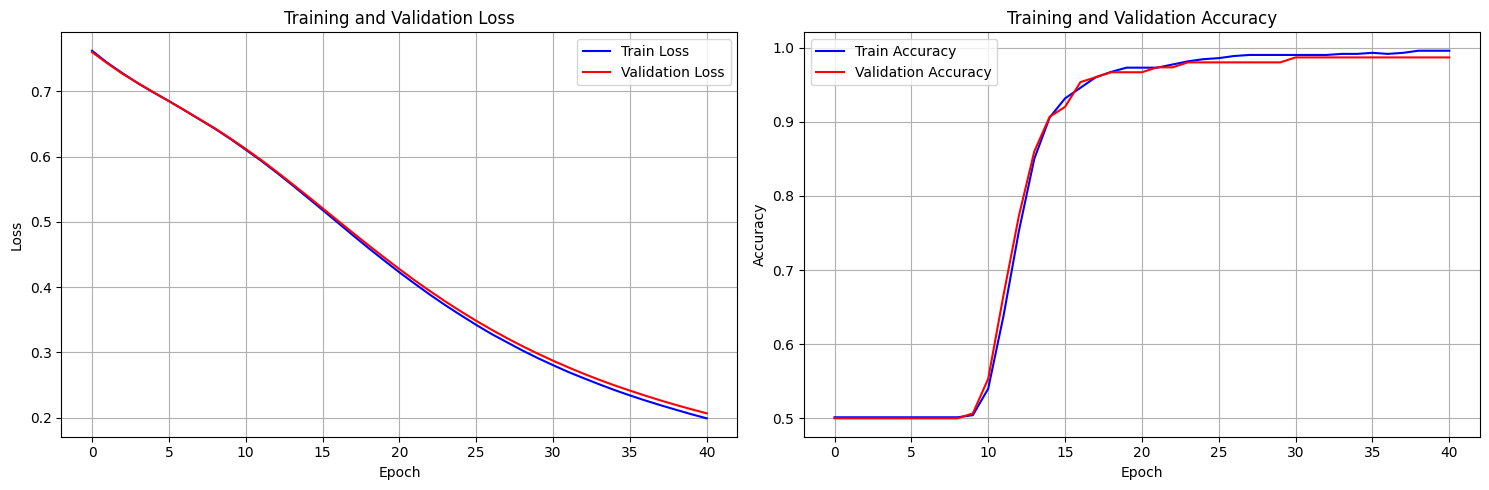

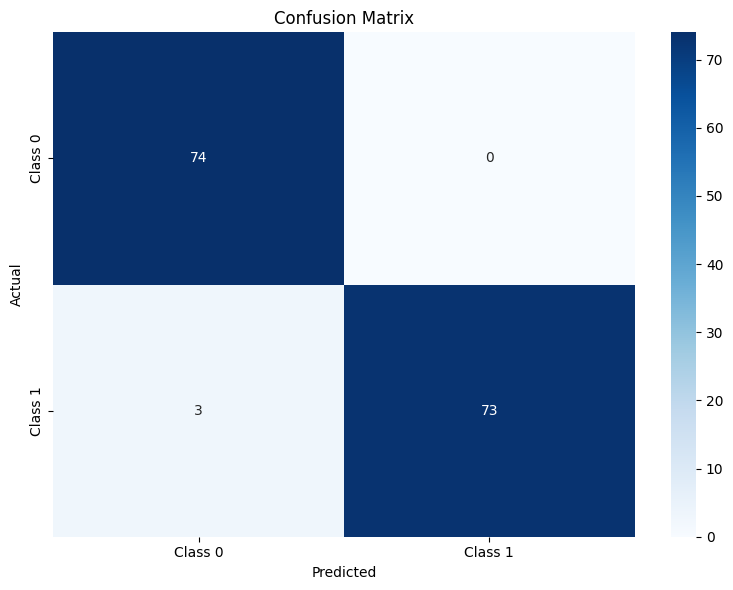

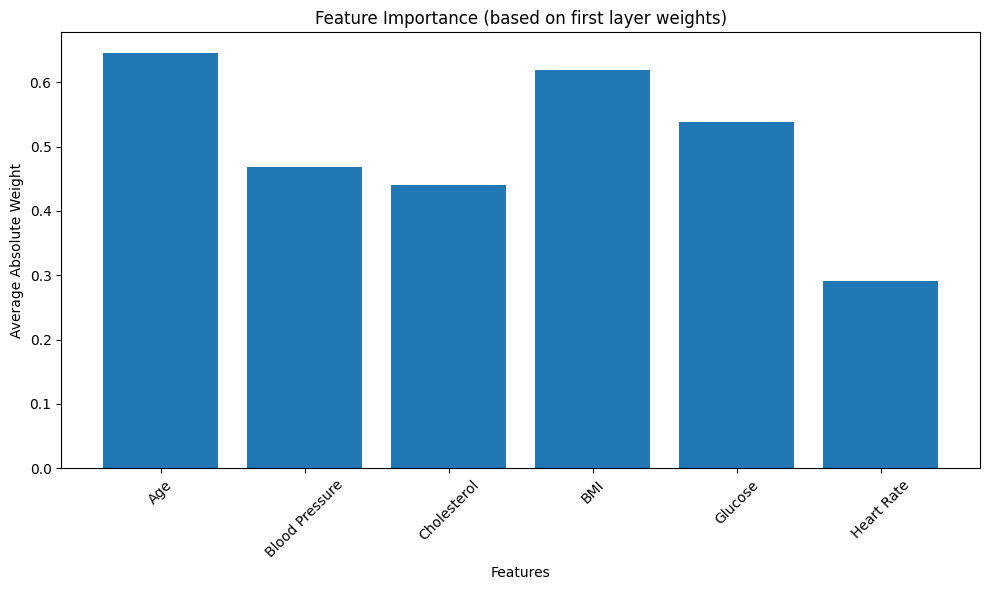


🔬 DEMO PREDICTION

📋 Sample Patient Cases:

🟢 Patient A (Healthy indicators):
   [Age:45, BP:120, Chol:180, BMI:24, Glucose:90, HR:70]
   Prediction Probability: 0.1535
   Predicted Class: HEALTHY (Class 0)

🔴 Patient B (High-risk indicators):
   [Age:65, BP:155, Chol:280, BMI:32, Glucose:180, HR:95]
   Prediction Probability: 0.7298
   Predicted Class: SICK (Class 1)

💾 Saving model...
   Model saved as 'binary_classifier_model.pth'

✅ Training complete!


In [13]:
"""
Simple Binary Classification Neural Network - Google Colab Version
A complete implementation of a feedforward neural network for binary classification
"""

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import copy
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

class BinaryClassifier(nn.Module):
    """
    A simple feedforward neural network for binary classification

    Architecture:
    - Input Layer: 6 features
    - Hidden Layer 1: 4 neurons with ReLU activation
    - Hidden Layer 2: 4 neurons with Sigmoid activation
    - Output: 1 neuron with Sigmoid (binary probability)
    """

    def __init__(self, input_size=6, hidden_size=4, output_size=1):
        super(BinaryClassifier, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.Sigmoid(),  # Hidden layer activation
            nn.Linear(hidden_size, output_size),
            nn.Sigmoid()   # Output activation for binary classification
        )

    def forward(self, x):
        return self.model(x)


class DataGenerator:
    """Generate synthetic dataset for binary classification"""

    @staticmethod
    def generate_dataset(n_samples=1000, n_features=6, noise=0.1):
        """
        Generate synthetic dataset with 6 features
        Creates two classes with different statistical properties
        """
        # Class 0: Centered around 0 with some spread
        class0 = np.random.randn(n_samples // 2, n_features) * noise + 0

        # Class 1: Centered around 1 with some spread
        class1 = np.random.randn(n_samples // 2, n_features) * noise + 1

        # Combine data
        X = np.vstack([class0, class1])
        y = np.hstack([np.zeros(n_samples // 2), np.ones(n_samples // 2)])

        # Shuffle the data
        indices = np.random.permutation(n_samples)
        X = X[indices]
        y = y[indices]

        return X, y

    @staticmethod
    def generate_medical_dataset():
        """
        Generate a realistic medical diagnosis dataset
        Features: [age, blood_pressure, cholesterol, bmi, glucose, heart_rate]
        """
        n_samples = 1000

        # Healthy patients (class 0)
        healthy = np.array([
            np.random.normal(45, 10, n_samples//2),      # age
            np.random.normal(120, 10, n_samples//2),     # blood pressure
            np.random.normal(180, 20, n_samples//2),     # cholesterol
            np.random.normal(24, 3, n_samples//2),       # bmi
            np.random.normal(90, 10, n_samples//2),      # glucose
            np.random.normal(70, 10, n_samples//2)       # heart rate
        ]).T

        # Sick patients (class 1) - with elevated risk factors
        sick = np.array([
            np.random.normal(60, 10, n_samples//2),      # age (older)
            np.random.normal(140, 15, n_samples//2),     # blood pressure (higher)
            np.random.normal(240, 30, n_samples//2),     # cholesterol (higher)
            np.random.normal(30, 4, n_samples//2),       # bmi (higher)
            np.random.normal(140, 20, n_samples//2),     # glucose (higher)
            np.random.normal(85, 15, n_samples//2)       # heart rate (higher)
        ]).T

        X = np.vstack([healthy, sick])
        y = np.hstack([np.zeros(n_samples//2), np.ones(n_samples//2)])

        # Shuffle
        indices = np.random.permutation(n_samples)
        return X[indices], y[indices]


class Trainer:
    """Handle model training and evaluation"""

    def __init__(self, model, criterion, optimizer, device='cpu'):
        self.model = model.to(device)
        self.criterion = criterion
        self.optimizer = optimizer
        self.device = device
        self.train_losses = []
        self.val_losses = []
        self.train_accuracies = []
        self.val_accuracies = []

    def train_epoch(self, train_loader):
        """Train for one epoch"""
        self.model.train()
        total_loss = 0
        correct = 0
        total = 0

        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(self.device), batch_y.to(self.device)

            # Forward pass
            outputs = self.model(batch_X)
            loss = self.criterion(outputs, batch_y)

            # Backward pass
            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()

            # Statistics
            total_loss += loss.item()
            predicted = (outputs > 0.5).float()
            total += batch_y.size(0)
            correct += (predicted == batch_y).sum().item()

        return total_loss / len(train_loader), correct / total

    def validate(self, val_loader):
        """Validate the model"""
        self.model.eval()
        total_loss = 0
        correct = 0
        total = 0
        all_predictions = []
        all_labels = []

        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X, batch_y = batch_X.to(self.device), batch_y.to(self.device)

                outputs = self.model(batch_X)
                loss = self.criterion(outputs, batch_y)

                total_loss += loss.item()
                predicted = (outputs > 0.5).float()
                total += batch_y.size(0)
                correct += (predicted == batch_y).sum().item()

                all_predictions.extend(predicted.cpu().numpy())
                all_labels.extend(batch_y.cpu().numpy())

        return (total_loss / len(val_loader), correct / total,
                np.array(all_predictions), np.array(all_labels))

    def train(self, train_loader, val_loader, epochs=100, early_stopping_patience=10):
        """Full training loop"""
        best_val_acc = 0
        patience_counter = 0
        best_model_state = None

        for epoch in range(epochs):
            # Train
            train_loss, train_acc = self.train_epoch(train_loader)
            self.train_losses.append(train_loss)
            self.train_accuracies.append(train_acc)

            # Validate
            val_loss, val_acc, _, _ = self.validate(val_loader)
            self.val_losses.append(val_loss)
            self.val_accuracies.append(val_acc)

            # Print progress
            if (epoch + 1) % 10 == 0:
                print(f'Epoch [{epoch+1}/{epochs}], '
                      f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, '
                      f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')

            # Early stopping
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                patience_counter = 0
                best_model_state = copy.deepcopy(self.model.state_dict())
            else:
                patience_counter += 1

            if patience_counter >= early_stopping_patience:
                print(f'Early stopping at epoch {epoch+1}')
                break

        # Load best model
        if best_model_state:
            self.model.load_state_dict(best_model_state)

        return self.model


class Visualizer:
    """Handle all visualization tasks"""

    @staticmethod
    def plot_training_history(trainer):
        """Plot training and validation loss/accuracy"""
        fig, axes = plt.subplots(1, 2, figsize=(15, 5))

        # Plot losses
        axes[0].plot(trainer.train_losses, label='Train Loss', color='blue')
        axes[0].plot(trainer.val_losses, label='Validation Loss', color='red')
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Loss')
        axes[0].set_title('Training and Validation Loss')
        axes[0].legend()
        axes[0].grid(True)

        # Plot accuracies
        axes[1].plot(trainer.train_accuracies, label='Train Accuracy', color='blue')
        axes[1].plot(trainer.val_accuracies, label='Validation Accuracy', color='red')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Accuracy')
        axes[1].set_title('Training and Validation Accuracy')
        axes[1].legend()
        axes[1].grid(True)

        plt.tight_layout()
        plt.show()

    @staticmethod
    def plot_confusion_matrix(y_true, y_pred):
        """Plot confusion matrix"""
        cm = confusion_matrix(y_true, y_pred)

        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                   xticklabels=['Class 0', 'Class 1'],
                   yticklabels=['Class 0', 'Class 1'])
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.title('Confusion Matrix')
        plt.tight_layout()
        plt.show()

    @staticmethod
    def plot_feature_importance(model, feature_names=None):
        """Simple feature importance visualization using first layer weights"""
        weights = model.model[0].weight.data.cpu().numpy()
        importance = np.abs(weights).mean(axis=0)

        if feature_names is None:
            feature_names = [f'Feature {i}' for i in range(len(importance))]
        else:
            feature_names = ['Age', 'Blood Pressure', 'Cholesterol', 'BMI', 'Glucose', 'Heart Rate']

        plt.figure(figsize=(10, 6))
        plt.bar(feature_names, importance)
        plt.xlabel('Features')
        plt.ylabel('Average Absolute Weight')
        plt.title('Feature Importance (based on first layer weights)')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()


# ===================== MAIN EXECUTION =====================
print("="*50)
print("BINARY CLASSIFICATION NEURAL NETWORK")
print("="*50)

# Configuration (you can modify these values)
config = {
    'epochs': 100,
    'batch_size': 32,
    'learning_rate': 0.001,
    'hidden_size': 4,
    'noise': 0.1,
    'use_medical_data': True  # Set to False for simple synthetic data
}

print("\n📋 Configuration:")
for key, value in config.items():
    print(f"   {key}: {value}")

# Generate data
print("\n📊 Generating dataset...")
if config['use_medical_data']:
    X, y = DataGenerator.generate_medical_dataset()
    feature_names = ['Age', 'Blood Pressure', 'Cholesterol', 'BMI', 'Glucose', 'Heart Rate']
    print("   Using medical diagnosis dataset")
else:
    X, y = DataGenerator.generate_dataset(n_samples=1000, n_features=6, noise=config['noise'])
    feature_names = None
    print("   Using synthetic dataset")

print(f"   Dataset shape: {X.shape}")
print(f"   Class distribution: {np.bincount(y.astype(int))}")

# Split data
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Normalize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Convert to tensors
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.FloatTensor(y_train).view(-1, 1)
X_val_tensor = torch.FloatTensor(X_val)
y_val_tensor = torch.FloatTensor(y_val).view(-1, 1)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.FloatTensor(y_test).view(-1, 1)

# Create data loaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=config['batch_size'], shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=config['batch_size'])
test_loader = DataLoader(test_dataset, batch_size=config['batch_size'])

# Initialize model
print("\n🧠 Building neural network...")
model = BinaryClassifier(input_size=6, hidden_size=config['hidden_size'])
criterion = nn.BCELoss()  # Binary Cross Entropy Loss
optimizer = optim.Adam(model.parameters(), lr=config['learning_rate'])

print(f"   Model architecture:\n{model}")

# Train model
print("\n🎯 Starting training...")
trainer = Trainer(model, criterion, optimizer, device)
trained_model = trainer.train(train_loader, val_loader, epochs=config['epochs'])

# Evaluate on test set
print("\n📈 Evaluating on test set...")
test_loss, test_acc, test_preds, test_labels = trainer.validate(test_loader)

# Calculate additional metrics
precision = precision_score(test_labels, test_preds)
recall = recall_score(test_labels, test_preds)
f1 = f1_score(test_labels, test_preds)

print(f"\n📊 Test Results:")
print(f"   Accuracy:  {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"   Precision: {precision:.4f}")
print(f"   Recall:    {recall:.4f}")
print(f"   F1-Score:  {f1:.4f}")

# Visualizations
print("\n🎨 Generating visualizations...")
viz = Visualizer()
viz.plot_training_history(trainer)
viz.plot_confusion_matrix(test_labels, test_preds)
viz.plot_feature_importance(trained_model, feature_names)

# Demo prediction
print("\n" + "="*50)
print("🔬 DEMO PREDICTION")
print("="*50)

# Create sample inputs
print("\n📋 Sample Patient Cases:")

# Healthy example
healthy_sample = np.array([[45, 120, 180, 24, 90, 70]])
healthy_scaled = scaler.transform(healthy_sample)
healthy_tensor = torch.FloatTensor(healthy_scaled).to(device)

with torch.no_grad():
    prediction = trained_model(healthy_tensor)
    probability = prediction.item()
    class_pred = "SICK (Class 1)" if probability > 0.5 else "HEALTHY (Class 0)"

print(f"\n🟢 Patient A (Healthy indicators):")
print(f"   [Age:45, BP:120, Chol:180, BMI:24, Glucose:90, HR:70]")
print(f"   Prediction Probability: {probability:.4f}")
print(f"   Predicted Class: {class_pred}")

# Sick example
sick_sample = np.array([[65, 155, 280, 32, 180, 95]])
sick_scaled = scaler.transform(sick_sample)
sick_tensor = torch.FloatTensor(sick_scaled).to(device)

with torch.no_grad():
    prediction = trained_model(sick_tensor)
    probability = prediction.item()
    class_pred = "SICK (Class 1)" if probability > 0.5 else "HEALTHY (Class 0)"

print(f"\n🔴 Patient B (High-risk indicators):")
print(f"   [Age:65, BP:155, Chol:280, BMI:32, Glucose:180, HR:95]")
print(f"   Prediction Probability: {probability:.4f}")
print(f"   Predicted Class: {class_pred}")

# Save model (optional - for Colab you might want to download it)
print("\n💾 Saving model...")
torch.save({
    'model_state_dict': trained_model.state_dict(),
    'scaler': scaler,
    'config': config
}, 'binary_classifier_model.pth')
print("   Model saved as 'binary_classifier_model.pth'")

# Download model in Colab (uncomment if you want to download)
# from google.colab import files
# files.download('binary_classifier_model.pth')

print("\n✅ Training complete!")